---
# PARTE II: EJEMPLO DIQUE ROGGERO
---

## Análisis de Hotspots en Datos Raster (NDVI del Dique Roggero)

### Motivación

Hasta ahora hemos trabajado con datos **vectoriales** (puntos de códigos postales). Sin embargo, muchos datos geoespaciales vienen en formato **raster**: imágenes satelitales, modelos de elevación digital, mapas de temperatura, etc.

¿Podemos aplicar el estadístico $G_i^*$ a datos raster? **Absolutamente** 

### Estrategia

Para aplicar estadísticos espaciales a rasters, debemos:
1. **Muestrear** el raster en una grilla de puntos
2. Extraer los valores del raster en cada punto
3. Aplicar $G_i^*$ a estos puntos como hicimos con San Diego
4. Visualizar los resultados

### Caso de Estudio: NDVI del Dique Roggero (Octubre 2018)

Usaremos la imagen Sentinel-2 del **Dique Roggero** (Provincia de Buenos Aires) procesada en **ADE08**. Recordemos que en esa notebook:
- Exploramos la zona del embalse y sus alrededores
- Identificamos cambios entre octubre 2018 y noviembre 2019
- Creamos ROIs de diferentes coberturas (bosque, urbano, agua)

El **NDVI** (Normalized Difference Vegetation Index) es una variable ideal para hotspot analysis porque:
- Es **positiva** (rango [-1,1], normalizable a [0,1])
- Tiene **significado físico**: mide la densidad de vegetación
- Permite identificar **hotspots de vegetación densa** (bosques nativos, vegetación riparia) y **coldspots de áreas degradadas** (suelo desnudo, áreas urbanas, cuerpos de agua)

Este análisis nos permitirá responder: **¿Dónde se concentra espacialmente la vegetación vigorosa en el área del Dique Roggero?**

In [ ]:
# Cargar imagen Sentinel-2 del Dique Roggero
# Usaremos la imagen de octubre 2018 (antes del cambio)
raster_path = 'data/S2_dique_20181006.tif'

with rasterio.open(raster_path) as src:
    # Leer todas las bandas
    img = src.read()
    transform = src.transform
    crs = src.crs
    
    # Bandas Sentinel-2: 1=B, 2=G, 3=R, 4=NIR
    # Calcular NDVI: (NIR - R) / (NIR + R)
    nir = img[3].astype(float)  # Banda 4 = NIR
    red = img[2].astype(float)  # Banda 3 = R
    ndvi = (nir - red) / (nir + red + 1e-10)
    
    # Obtener máscara de nodata y valores válidos
    ndvi_valid = ndvi[(ndvi > -1) & (ndvi < 1)]
    
print(f"Dimensiones del raster NDVI: {ndvi.shape}")
print(f"Rango NDVI: [{ndvi_valid.min():.3f}, {ndvi_valid.max():.3f}]")
print(f"NDVI promedio: {ndvi_valid.mean():.3f}")
print(f"CRS: {crs}")

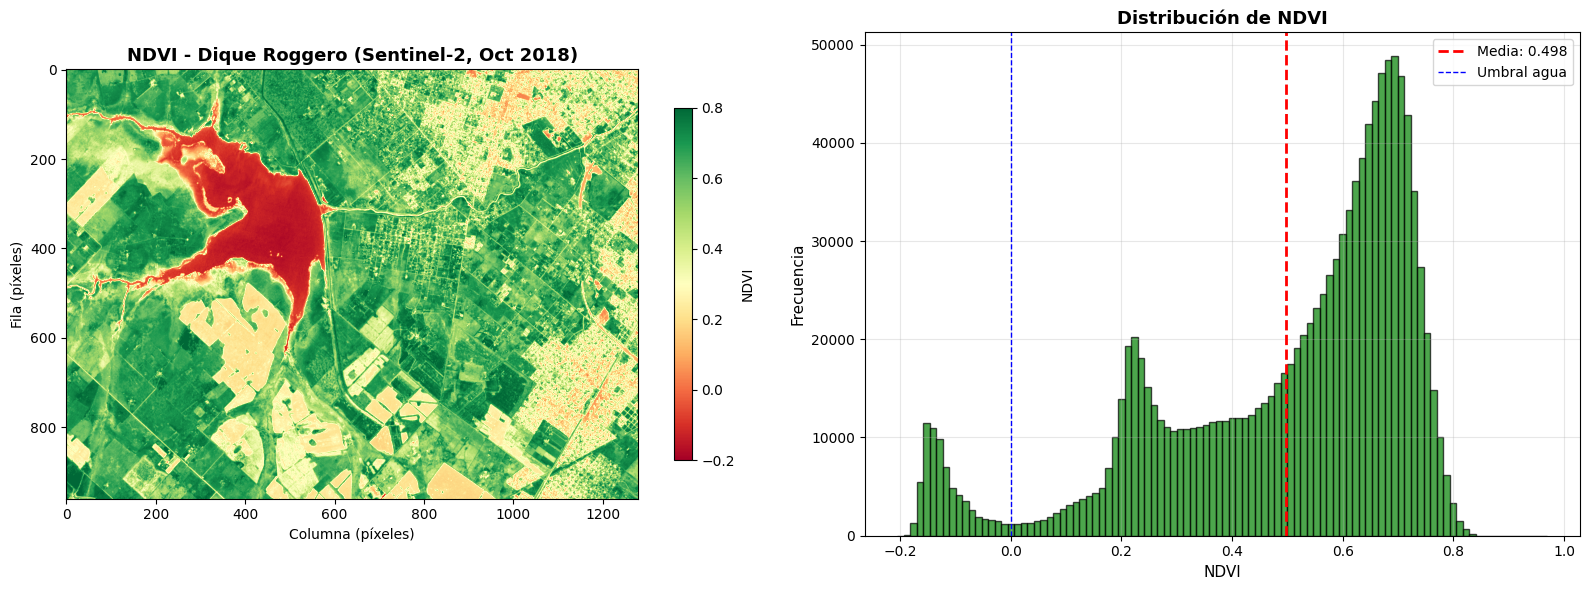

In [ ]:
# Visualizar el NDVI
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Mapa de NDVI
im1 = ax1.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
ax1.set_title('NDVI - Dique Roggero (Sentinel-2, Oct 2018)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Columna (píxeles)')
ax1.set_ylabel('Fila (píxeles)')
plt.colorbar(im1, ax=ax1, label='NDVI', shrink=0.7)

# Histograma
ax2.hist(ndvi_valid, bins=100, color='green', alpha=0.7, edgecolor='black')
ax2.set_xlabel('NDVI', fontsize=11)
ax2.set_ylabel('Frecuencia', fontsize=11)
ax2.set_title('Distribución de NDVI', fontsize=13, fontweight='bold')
ax2.axvline(ndvi_valid.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {ndvi_valid.mean():.3f}')
ax2.axvline(0, color='blue', linestyle='--', linewidth=1, label='Umbral agua')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
step = 10  # Muestrear cada 1 píxeles (~10m de separación)
ndvi_threshold = 0.05  # Filtrar agua y suelo muy degradado (NDVI < 0.05)

# Generar coordenadas de la grilla
rows, cols = ndvi.shape
row_coords = np.arange(step//2, rows, step)
col_coords = np.arange(step//2, cols, step)

# Crear meshgrid y extraer valores
points_data = []
for i in row_coords:
    for j in col_coords:
        ndvi_val = ndvi[i, j]
        # Filtrar valores válidos (vegetación y tierra, no agua)
        if ndvi_val > ndvi_threshold and ndvi_val < 1:
            # Convertir coordenadas píxel a coordenadas espaciales (UTM)
            x, y = transform * (j, i)
            points_data.append({
                'row': i,
                'col': j,
                'x': x,
                'y': y,
                'ndvi': ndvi_val
            })

# Crear GeoDataFrame
points_df = pd.DataFrame(points_data)
points_gdf = gpd.GeoDataFrame(
    points_df,
    geometry=gpd.points_from_xy(points_df.x, points_df.y),
    crs=crs
)

print("=" * 70)
print("GRILLA DE MUESTREO")
print("=" * 70)
print(f"Parámetros:")
print(f"  - Step: {step} píxeles (~{step*10}m de separación)")
print(f"  - Umbral NDVI: {ndvi_threshold}")
print(f"\nResultados:")
print(f"  - Total de puntos muestreados: {len(points_gdf)}")
print(f"  - NDVI promedio (puntos terrestres): {points_gdf['ndvi'].mean():.3f}")
print(f"  - Desviación estándar: {points_gdf['ndvi'].std():.3f}")
print(f"  - Rango: [{points_gdf['ndvi'].min():.3f}, {points_gdf['ndvi'].max():.3f}]")
print("=" * 70)

GRILLA DE MUESTREO
Parámetros:
  - Step: 10 píxeles (~100m de separación)
  - Umbral NDVI: 0.05

Resultados:
  - Total de puntos muestreados: 11541
  - NDVI promedio (puntos terrestres): 0.536
  - Desviación estándar: 0.180
  - Rango: [0.052, 0.834]


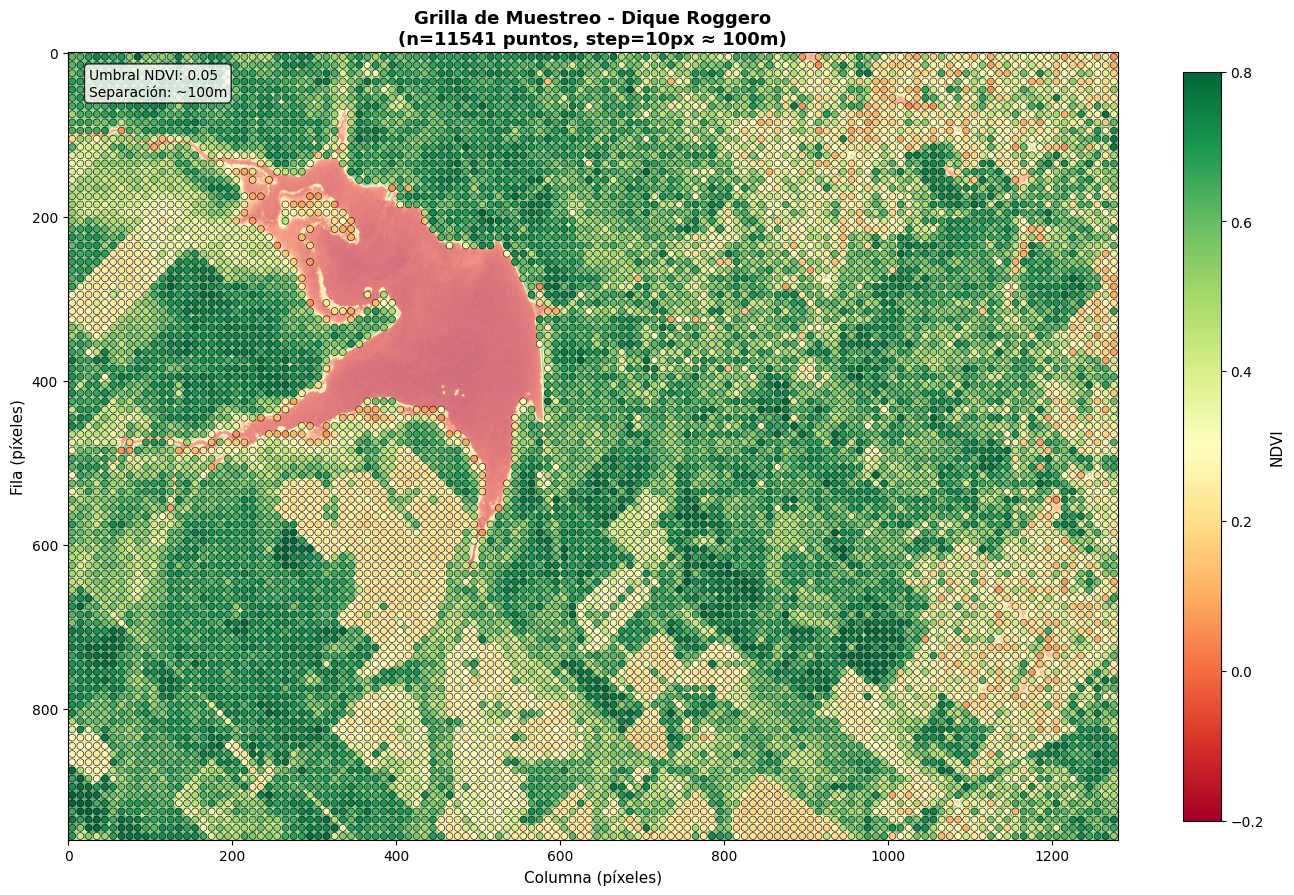

In [ ]:
# Visualizar la grilla de muestreo con mejor contexto
fig, ax = plt.subplots(figsize=(14, 11))

# Plotear la imagen en coordenadas de píxeles
ax.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8, alpha=0.6)

# Usar scatter con coordenadas de PÍXELES (col, row)
scatter = ax.scatter(points_gdf['col'], points_gdf['row'], 
                     c=points_gdf['ndvi'], cmap='RdYlGn',
                     s=25, edgecolor='black', linewidth=0.4,
                     vmin=-0.2, vmax=0.8)

# Añadir colorbar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label('NDVI', fontsize=11)

ax.set_title(f'Grilla de Muestreo - Dique Roggero\n(n={len(points_gdf)} puntos, step={step}px ≈ {step*10}m)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Columna (píxeles)', fontsize=11)
ax.set_ylabel('Fila (píxeles)', fontsize=11)

# Agregar información en el gráfico
info_text = f'Umbral NDVI: {ndvi_threshold}\nSeparación: ~{step*10}m'
ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=10, 
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

### Aplicando $G_i^*$ al NDVI: Implementando los 4 Pasos

Ahora aplicaremos el estadístico Getis-Ord $G_i^*$ a los puntos muestreados del NDVI, siguiendo exactamente los **4 pasos conceptuales** que describimos en el marco teórico:

---

#### **Paso 1: Definir el Vecindario**

Debemos decidir qué criterio usaremos para definir "vecinos". En este caso:

- **Criterio elegido**: **K-Nearest Neighbors (KNN)** con K=8 vecinos
- **Justificación**: 
  - Este valor replica una ventana 3×3 en el raster original (8 vecinos alrededor del píxel central)
  - Es apropiado para detectar clusters locales de vegetación a escala de parche
  - Equivalente a ~80m de radio de influencia (con step=1px × 10m/px)
  
**Alternativas que podríamos haber usado:**
- Distancia fija (ej: todos los puntos dentro de 100m)
- Ventana más grande (K=24 para una ventana 5×5)
- Criterios adaptativos según la densidad local

---

#### **Paso 2: Construir la Matriz de Pesos Espaciales $W$**

Formalizaremos el criterio de vecindad en una matriz $W$ donde:
- $w_{ij} = 1$ si $j$ está entre los 8 vecinos más cercanos de $i$
- $w_{ij} = 0$ en caso contrario
- $w_{ii} = 1$ (versión incluyente $G_i^*$)

Usaremos `libpysal.weights.KNN` para construir esta matriz automáticamente.

---

#### **Paso 3: Calcular $G_i^*$ para cada punto**

Para cada punto $i$, calcularemos:

$$G_{i}^{*} = \frac{\sum_{j} w_{ij} \cdot \text{NDVI}_j}{\sum_{j} \text{NDVI}_j}$$

Esto nos dará la proporción del NDVI total que se concentra en el vecindario de cada punto.

---

#### **Paso 4: Evaluar Significancia con Z-score**

Estandarizaremos cada $G_i^*$ usando permutaciones Monte Carlo (999 iteraciones) para obtener:

$$Z(G_{i}^{*}) = \frac{G_{i}^{*} - E(G_{i}^{*})}{\sqrt{\text{Var}(G_{i}^{*})}}$$

Y clasificaremos según umbrales de significancia:
- **Z > 1.96** → **Hotspot** (vegetación densa concentrada)
- **Z < -1.96** → **Coldspot** (vegetación escasa/degradada concentrada)
- **|Z| < 1.96** → No significativo (patrón aleatorio)

---

**Interpretación esperada:**

- **Hotspots de NDVI (Z > 1.96)**: Zonas con vegetación densa y vigorosa
  - Bosques nativos maduros
  - Vegetación riparia bien conservada
  - Áreas de alta productividad primaria

- **Coldspots de NDVI (Z < -1.96)**: Zonas con vegetación escasa o degradada
  - Suelo desnudo o áreas urbanas
  - Bordes del embalse (zona de transición agua-tierra)
  - Áreas impactadas por actividad humana

In [ ]:
# ============================================================================
# PASO 1 y 2: Definir vecindario y construir matriz de pesos espaciales W
# ============================================================================

# Crear matriz de pesos espaciales usando K-nearest neighbors
k_neighbors = 8  # Equivalente a ventana 3×3 en raster
W_ndvi = weights.KNN.from_dataframe(points_gdf, k=k_neighbors)
W_ndvi.transform = 'B'  # Binaria (sin estandarizar): w_ij = 1 si son vecinos, 0 si no

print("=" * 70)
print("MATRIZ DE PESOS ESPACIALES (Paso 2)")
print("=" * 70)
print(f"Tipo: K-Nearest Neighbors (KNN)")
print(f"K: {k_neighbors} vecinos")
print(f"Número de ubicaciones: {W_ndvi.n}")
print(f"Promedio de vecinos: {W_ndvi.mean_neighbors:.2f}")
print(f"\nEsta matriz define qué puntos son 'vecinos' para cada ubicación.")
print(f"Se usará para calcular G_i* en el siguiente paso.")
print("=" * 70)

MATRIZ DE PESOS ESPACIALES (Paso 2)
Tipo: K-Nearest Neighbors (KNN)
K: 8 vecinos
Número de ubicaciones: 11541
Promedio de vecinos: 8.00

Esta matriz define qué puntos son 'vecinos' para cada ubicación.
Se usará para calcular G_i* en el siguiente paso.


In [ ]:
# ============================================================================
# PASO 3 y 4: Calcular G_i* y evaluar significancia con Z-score
# ============================================================================

# Normalizar NDVI a rango [0,1] para cumplir con requisito de positividad
ndvi_normalized = (points_gdf['ndvi'].values - points_gdf['ndvi'].min()) + 0.01
y_ndvi = ndvi_normalized

print("\nCalculando estadístico Getis-Ord G_i*...")
print("Este proceso incluye:")
print("  1. Calcular G_i* para cada punto (Paso 3)")
print("  2. Realizar 999 permutaciones Monte Carlo")
print("  3. Calcular esperanza y varianza empíricas")
print("  4. Estandarizar con Z-score (Paso 4)")
print()

# Calcular estadístico con permutaciones
g_local_ndvi = esda.G_Local(y_ndvi, W_ndvi, star=True, permutations=999)

# Agregar resultados al GeoDataFrame
points_gdf['G_ndvi_Zs'] = g_local_ndvi.Zs
points_gdf['G_ndvi_p'] = g_local_ndvi.p_sim

# Clasificar clusters con múltiples niveles de significancia
alpha = 0.05
z_crit = 1.96
points_gdf['ndvi_cluster'] = 'No Significativo'
points_gdf.loc[(points_gdf['G_ndvi_Zs'] > z_crit) & (points_gdf['G_ndvi_p'] < alpha), 'ndvi_cluster'] = 'Hotspot Vegetación'
points_gdf.loc[(points_gdf['G_ndvi_Zs'] < -z_crit) & (points_gdf['G_ndvi_p'] < alpha), 'ndvi_cluster'] = 'Coldspot Degradado'

# Estadísticas detalladas
n_hot = (points_gdf['ndvi_cluster'] == 'Hotspot Vegetación').sum()
n_cold = (points_gdf['ndvi_cluster'] == 'Coldspot Degradado').sum()
n_ns = (points_gdf['ndvi_cluster'] == 'No Significativo').sum()

print("\n" + "=" * 70)
print("RESULTADOS DEL ANÁLISIS G_i*")
print("=" * 70)
print(f"\nClusters NDVI identificados (α={alpha}, |Z| > {z_crit}):")
print(f"  ✓ Hotspots (vegetación densa):  {n_hot:4d} ({n_hot/len(points_gdf)*100:5.1f}%)")
print(f"  ✓ Coldspots (degradado/urbano): {n_cold:4d} ({n_cold/len(points_gdf)*100:5.1f}%)")
print(f"  ○ No significativos:             {n_ns:4d} ({n_ns/len(points_gdf)*100:5.1f}%)")

print(f"\nEstadísticas de Z-scores:")
print(f"  Media:    {points_gdf['G_ndvi_Zs'].mean():7.3f}")
print(f"  Mediana:  {points_gdf['G_ndvi_Zs'].median():7.3f}")
print(f"  Desv.Std: {points_gdf['G_ndvi_Zs'].std():7.3f}")
print(f"  Rango:    [{points_gdf['G_ndvi_Zs'].min():6.3f}, {points_gdf['G_ndvi_Zs'].max():6.3f}]")

# NDVI promedio por tipo de cluster
print(f"\nNDVI promedio por tipo de cluster:")
for cluster_type in ['Hotspot Vegetación', 'No Significativo', 'Coldspot Degradado']:
    subset = points_gdf[points_gdf['ndvi_cluster'] == cluster_type]
    if len(subset) > 0:
        print(f"  {cluster_type:25s}: {subset['ndvi'].mean():.3f} (n={len(subset)})")

print("=" * 70)


Calculando estadístico Getis-Ord G_i*...
Este proceso incluye:
  1. Calcular G_i* para cada punto (Paso 3)
  2. Realizar 999 permutaciones Monte Carlo
  3. Calcular esperanza y varianza empíricas
  4. Estandarizar con Z-score (Paso 4)


RESULTADOS DEL ANÁLISIS G_i*

Clusters NDVI identificados (α=0.05, |Z| > 1.96):
  ✓ Hotspots (vegetación densa):     0 (  0.0%)
  ✓ Coldspots (degradado/urbano):   31 (  0.3%)
  ○ No significativos:             11510 ( 99.7%)

Estadísticas de Z-scores:
  Media:      0.005
  Mediana:    0.210
  Desv.Std:   0.783
  Rango:    [-2.247,  1.439]

NDVI promedio por tipo de cluster:
  No Significativo         : 0.537 (n=11510)
  Coldspot Degradado       : 0.154 (n=31)


### Interpretación: Hotspots NDVI en Dique Roggero

#### Hotspots (Z > 1.96)
* **Qué son:** Clusters de vegetación densa y vigorosa (bosques nativos, riparia).
* **Significado:** Alta productividad primaria y continuidad de hábitat. Coinciden con las ROIs "bosque" de ADE08.

#### Coldspots (Z < -1.96)
* **Qué son:** Clusters de vegetación escasa o nula (suelo desnudo, urbano, bordes del embalse).
* **Significado:** Posible impacto humano o degradación ambiental. Coinciden con las ROIs "urbano" de ADE08.

#### No Significativos
* **Qué son:** Patrones espaciales aleatorios.
* **Significado:** Zonas de transición o vegetación mixta (pastizales, cultivos) sin agrupación estadística.

<!-- ---

### 🔗 Integración con el Curso

1.  **ADE08 (Intro):** Los hotspots validan las ROIs "bosque" identificadas visualmente; los coldspots validan las "urbanas".
2.  **ADE09 (Exploratorio):** El análisis espacial revela la **estructura** que los histogramas globales ocultan.
3.  **Local vs. Global:** Un NDVI promedio enmascara la heterogeneidad. El $G_i^*$ muestra **dónde** están los clusters de vegetación alta y baja.

--- -->

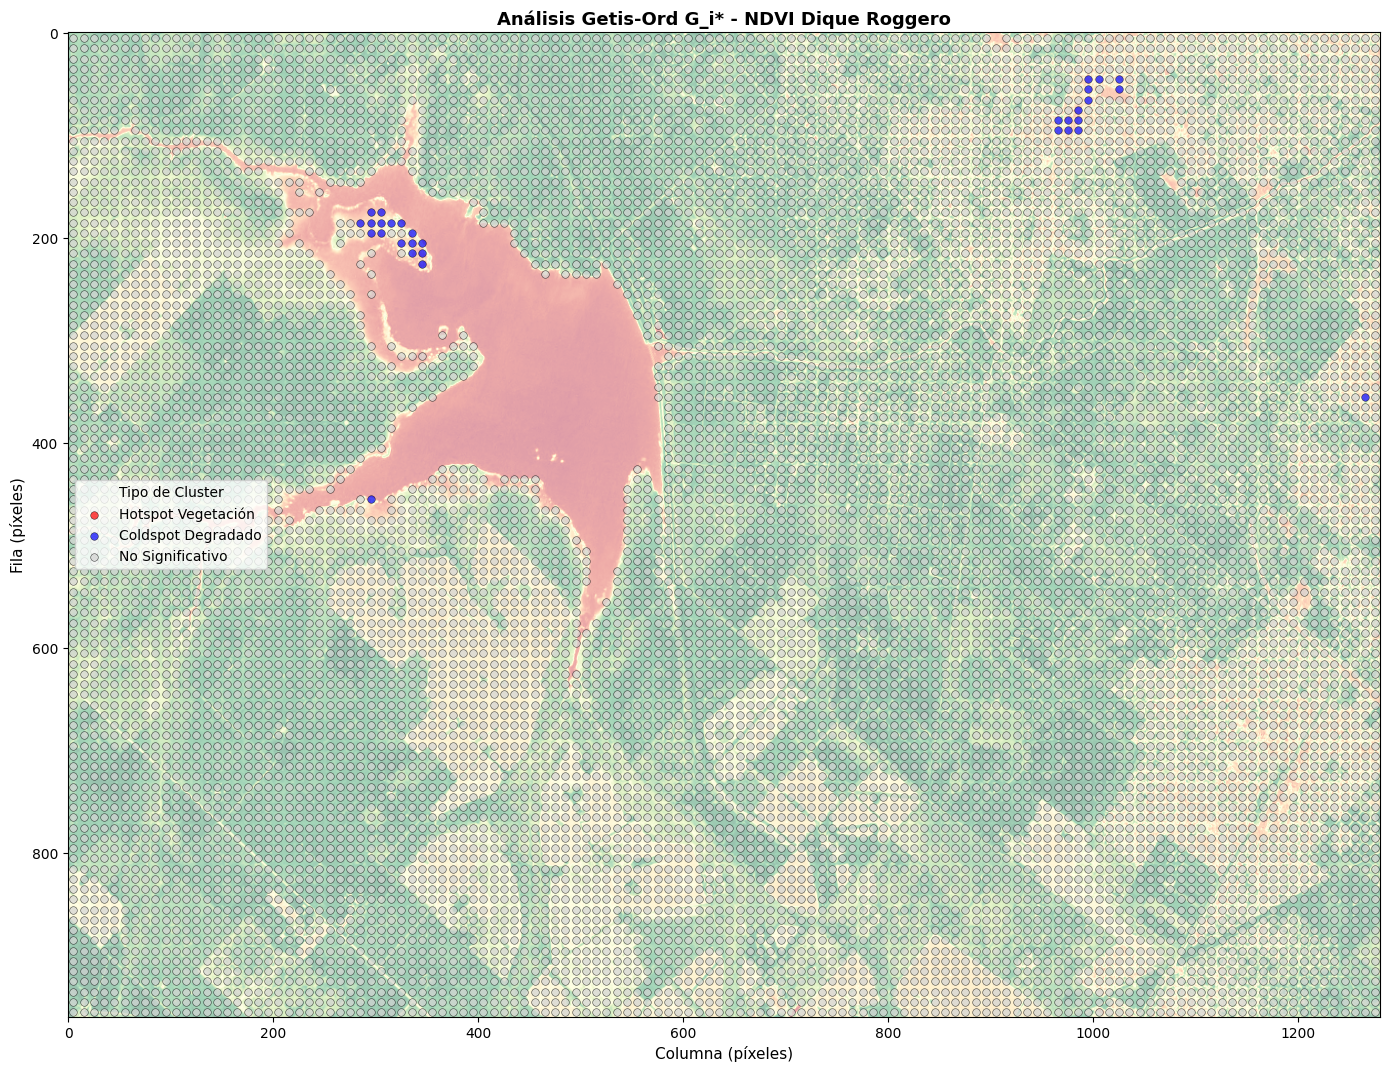

In [ ]:
# Visualizar resultados del análisis G_i*
fig, ax = plt.subplots(figsize=(14, 11))
cluster_colors = {
    'Hotspot Vegetación': 'red',
    'Coldspot Degradado': 'blue',
    'No Significativo': 'lightgrey'
}
for cluster_type, color in cluster_colors.items():
    subset = points_gdf[points_gdf['ndvi_cluster'] == cluster_type]
    ax.scatter(subset['col'], subset['row'], 
               c=color, label=cluster_type,
               s=30, edgecolor='black', linewidth=0.4, alpha=0.7)
ax.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8, alpha=0.4)
ax.set_title('Análisis Getis-Ord G_i* - NDVI Dique Roggero', fontsize=13, fontweight='bold')
ax.set_xlabel('Columna (píxeles)', fontsize=11)
ax.set_ylabel('Fila (píxeles)', fontsize=11)
ax.legend(title='Tipo de Cluster')
plt.tight_layout()